# Exploration des Données - Classification de Produits E-commerce

## Objectif
Prendre en main et découvrir le jeu de données pour mettre en lumière :
- La **structure** du dataset
- Les **difficultés** rencontrées
- Les **biais** éventuels

## Plan d'exploration
1. Chargement et première approche des données
2. Analyse de la qualité des données
3. Analyse de la variable cible (prdtypecode)
4. Analyse des variables textuelles (designation, description)
5. Analyse des identifiants
6. Comparaison train/test
7. Identification des biais
8. Visualisations clés



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Chemins des données
DATA_DIR = Path('../data brut')
TRAIN_X_FILE = DATA_DIR / 'X_train_update.csv'
TRAIN_Y_FILE = DATA_DIR / 'Y_train.csv'
TEST_X_FILE = DATA_DIR / 'X_test_update.csv'

print("✅ Bibliothèques importées avec succès")
print(f"📁 Dossier de données : {DATA_DIR}")



✅ Bibliothèques importées avec succès
📁 Dossier de données : ..\data brut


## 1. Chargement et Première Approche des Données

### Questions à répondre :
- Combien de lignes et de colonnes dans chaque fichier ?
- Quels sont les types de données de chaque colonne ?
- Les fichiers sont-ils bien alignés (même nombre de lignes entre X_train et Y_train) ?
- À quoi ressemblent les premières lignes ?



In [2]:
# Chargement des données
print("🔄 Chargement des données...")

X_train = pd.read_csv(TRAIN_X_FILE)
y_train = pd.read_csv(TRAIN_Y_FILE)
X_test = pd.read_csv(TEST_X_FILE)

print(f"\n✅ Données chargées avec succès !")
print(f"\n📊 Dimensions des datasets :")
print(f"  - X_train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"  - y_train : {y_train.shape[0]:,} lignes × {y_train.shape[1]} colonnes")
print(f"  - X_test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")

# Vérification de l'alignement
if X_train.shape[0] == y_train.shape[0]:
    print(f"\n✅ Alignement OK : X_train et y_train ont le même nombre de lignes")
else:
    print(f"\n⚠️  ATTENTION : X_train et y_train n'ont pas le même nombre de lignes !")



🔄 Chargement des données...

✅ Données chargées avec succès !

📊 Dimensions des datasets :
  - X_train : 84,916 lignes × 5 colonnes
  - y_train : 84,916 lignes × 2 colonnes
  - X_test  : 13,812 lignes × 5 colonnes

✅ Alignement OK : X_train et y_train ont le même nombre de lignes


In [3]:
# Aperçu des données
print("=" * 80)
print("APERÇU DE X_train")
print("=" * 80)
print(X_train.head())
print(f"\nTypes de données :\n{X_train.dtypes}")
print(f"\nInformations générales :")
X_train.info()



APERÇU DE X_train
   Unnamed: 0                                        designation  \
0           0  Olivia: Personalisiertes Notizbuch / 150 Seite...   
1           1  Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...   
2           2  Grand Stylet Ergonomique Bleu Gamepad Nintendo...   
3           3  Peluche Donald - Europe - Disneyland 2000 (Mar...   
4           4                               La Guerre Des Tuques   

                                         description   productid     imageid  
0                                                NaN  3804725264  1263597046  
1                                                NaN   436067568  1008141237  
2  PILOT STYLE Touch Pen de marque Speedlink est ...   201115110   938777978  
3                                                NaN    50418756   457047496  
4  Luc a des id&eacute;es de grandeur. Il veut or...   278535884  1077757786  

Types de données :
Unnamed: 0      int64
designation    object
description    object
productid    

In [4]:
# Aperçu de y_train
print("=" * 80)
print("APERÇU DE y_train")
print("=" * 80)
print(y_train.head())
print(f"\nTypes de données :\n{y_train.dtypes}")
print(f"\nValeurs uniques dans prdtypecode : {y_train['prdtypecode'].nunique()}")



APERÇU DE y_train
   Unnamed: 0  prdtypecode
0           0           10
1           1         2280
2           2           50
3           3         1280
4           4         2705

Types de données :
Unnamed: 0     int64
prdtypecode    int64
dtype: object

Valeurs uniques dans prdtypecode : 27


In [5]:
# Aperçu de X_test
print("=" * 80)
print("APERÇU DE X_test")
print("=" * 80)
print(X_test.head())
print(f"\nTypes de données :\n{X_test.dtypes}")
print(f"\nInformations générales :")
X_test.info()

# Vérification de la cohérence avec X_train
print("\n" + "=" * 80)
print("COMPARAISON X_train vs X_test")
print("=" * 80)
print(f"  - Colonnes identiques : {list(X_train.columns) == list(X_test.columns)}")
print(f"  - Types de données identiques : {X_train.dtypes.equals(X_test.dtypes)}")
print(f"  - Ratio de taille : X_test / X_train = {len(X_test) / len(X_train):.2%}")



APERÇU DE X_test
   Unnamed: 0                                        designation  \
0       84916  Folkmanis Puppets - 2732 - Marionnette Et Théâ...   
1       84917  Porte Flamme Gaxix - Flamebringer Gaxix - 136/...   
2       84918                  Pompe de filtration Speck Badu 95   
3       84919                        Robot de piscine électrique   
4       84920  Hsm Destructeur Securio C16 Coupe Crois¿E: 4 X...   

                                         description   productid     imageid  
0                                                NaN   516376098  1019294171  
1                                                NaN   133389013  1274228667  
2                                                NaN  4128438366  1295960357  
3  <p>Ce robot de piscine d&#39;un design innovan...  3929899732  1265224052  
4                                                NaN   152993898   940543690  

Types de données :
Unnamed: 0      int64
designation    object
description    object
productid     

## 2. Analyse de la Qualité des Données

### Questions à répondre :
- Combien de valeurs manquantes par colonne ?
- Y a-t-il des doublons ?
- Les identifiants sont-ils uniques ?
- Y a-t-il des patterns dans les valeurs manquantes ?



In [6]:
# Analyse des valeurs manquantes
print("=" * 80)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 80)

missing_train = X_train.isnull().sum()
missing_test = X_test.isnull().sum()
missing_y = y_train.isnull().sum()

print("\n📊 Valeurs manquantes dans X_train :")
print(missing_train)
print(f"\nPourcentage de valeurs manquantes dans X_train :")
print((missing_train / len(X_train) * 100).round(2))

print("\n📊 Valeurs manquantes dans X_test :")
print(missing_test)
print(f"\nPourcentage de valeurs manquantes dans X_test :")
print((missing_test / len(X_test) * 100).round(2))

print("\n📊 Valeurs manquantes dans y_train :")
print(missing_y)



ANALYSE DES VALEURS MANQUANTES

📊 Valeurs manquantes dans X_train :
Unnamed: 0         0
designation        0
description    29800
productid          0
imageid            0
dtype: int64

Pourcentage de valeurs manquantes dans X_train :
Unnamed: 0      0.00
designation     0.00
description    35.09
productid       0.00
imageid         0.00
dtype: float64

📊 Valeurs manquantes dans X_test :
Unnamed: 0        0
designation       0
description    4886
productid         0
imageid           0
dtype: int64

Pourcentage de valeurs manquantes dans X_test :
Unnamed: 0      0.00
designation     0.00
description    35.38
productid       0.00
imageid         0.00
dtype: float64

📊 Valeurs manquantes dans y_train :
Unnamed: 0     0
prdtypecode    0
dtype: int64


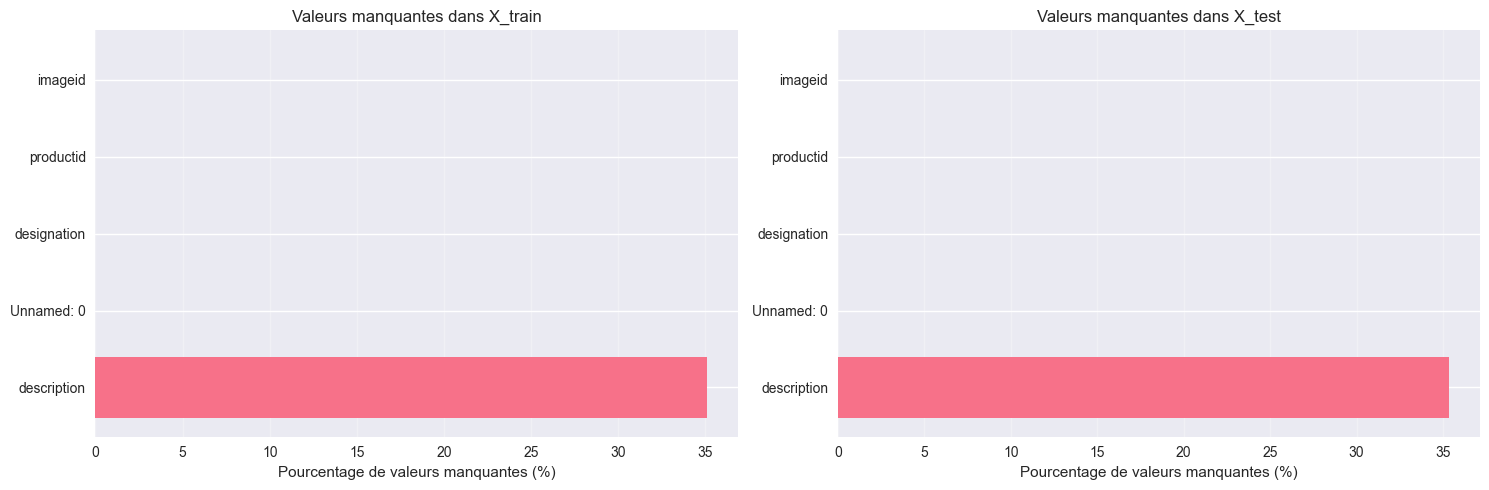

In [7]:
# Visualisation des valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# X_train
missing_train_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
axes[0].barh(missing_train_pct.index, missing_train_pct.values)
axes[0].set_xlabel('Pourcentage de valeurs manquantes (%)')
axes[0].set_title('Valeurs manquantes dans X_train')
axes[0].grid(axis='x', alpha=0.3)

# X_test
missing_test_pct = (X_test.isnull().sum() / len(X_test) * 100).sort_values(ascending=False)
axes[1].barh(missing_test_pct.index, missing_test_pct.values)
axes[1].set_xlabel('Pourcentage de valeurs manquantes (%)')
axes[1].set_title('Valeurs manquantes dans X_test')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



In [8]:
# Analyse des doublons
print("=" * 80)
print("ANALYSE DES DOUBLONS")
print("=" * 80)

print(f"\nDoublons dans X_train (lignes complètes) : {X_train.duplicated().sum()}")
print(f"Doublons dans X_test (lignes complètes) : {X_test.duplicated().sum()}")

# Vérification de l'unicité des productid
print(f"\nProductid uniques dans X_train : {X_train['productid'].nunique()} / {len(X_train)}")
print(f"Productid uniques dans X_test : {X_test['productid'].nunique()} / {len(X_test)}")

# Vérification de data leakage (productid du test présents dans le train)
if 'productid' in X_train.columns and 'productid' in X_test.columns:
    train_ids = set(X_train['productid'])
    test_ids = set(X_test['productid'])
    common_ids = train_ids.intersection(test_ids)
    print(f"\n⚠️  Productid communs entre train et test : {len(common_ids)}")
    if len(common_ids) > 0:
        print("   ATTENTION : Risque de data leakage !")



ANALYSE DES DOUBLONS

Doublons dans X_train (lignes complètes) : 0
Doublons dans X_test (lignes complètes) : 0

Productid uniques dans X_train : 84916 / 84916
Productid uniques dans X_test : 13812 / 13812

⚠️  Productid communs entre train et test : 0


## 3. Analyse de la Variable Cible (prdtypecode)

### Questions à répondre :
- Combien de classes différentes existent ?
- Quelle est la distribution des classes ?
- Y a-t-il un déséquilibre de classes ?
- Quelles sont les classes les plus/moins représentées ?



In [9]:
# Analyse de la distribution des classes
print("=" * 80)
print("ANALYSE DE LA VARIABLE CIBLE (prdtypecode)")
print("=" * 80)

class_counts = y_train['prdtypecode'].value_counts().sort_values(ascending=False)
n_classes = y_train['prdtypecode'].nunique()

print(f"\n📊 Nombre total de classes : {n_classes}")
print(f"\nTop 10 classes les plus représentées :")
print(class_counts.head(10))

print(f"\nTop 10 classes les moins représentées :")
print(class_counts.tail(10))

# Statistiques sur le déséquilibre
max_class = class_counts.max()
min_class = class_counts.min()
ratio = max_class / min_class

print(f"\n📈 Statistiques de déséquilibre :")
print(f"  - Classe la plus fréquente : {max_class} occurrences")
print(f"  - Classe la moins fréquente : {min_class} occurrences")
print(f"  - Ratio max/min : {ratio:.2f}")

# Classes avec très peu d'exemples
rare_classes = class_counts[class_counts < 10]
print(f"\n⚠️  Classes avec moins de 10 exemples : {len(rare_classes)}")
if len(rare_classes) > 0:
    print(rare_classes)



ANALYSE DE LA VARIABLE CIBLE (prdtypecode)

📊 Nombre total de classes : 27

Top 10 classes les plus représentées :
prdtypecode
2583    10209
1560     5073
1300     5045
2060     4993
2522     4989
1280     4870
2403     4774
2280     4760
1920     4303
1160     3953
Name: count, dtype: int64

Top 10 classes les moins représentées :
prdtypecode
1302    2491
1281    2070
50      1681
2462    1421
2905     872
60       832
2220     824
1301     807
1940     803
1180     764
Name: count, dtype: int64

📈 Statistiques de déséquilibre :
  - Classe la plus fréquente : 10209 occurrences
  - Classe la moins fréquente : 764 occurrences
  - Ratio max/min : 13.36

⚠️  Classes avec moins de 10 exemples : 0


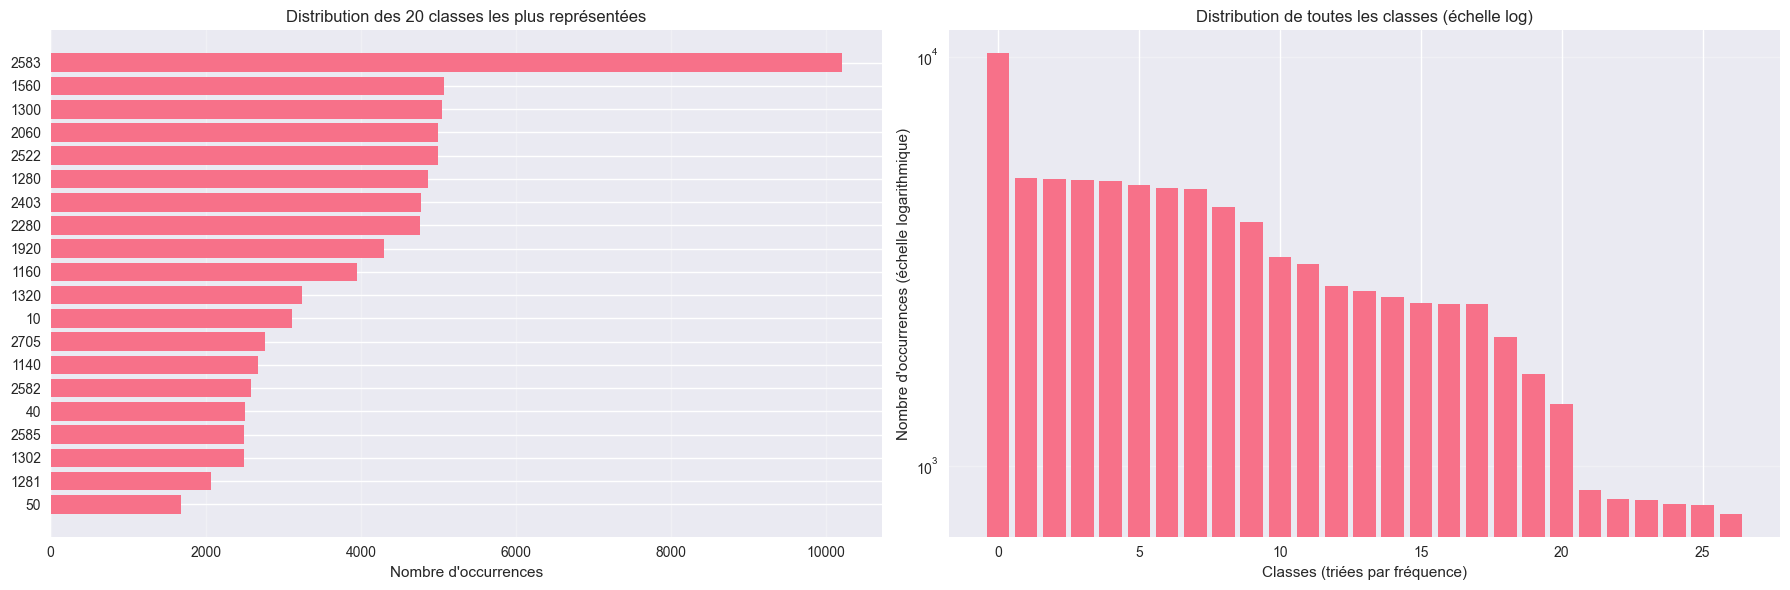


✅ Visualisation 1 créée : Distribution des classes


In [10]:
# Visualisation 1 : Distribution des classes (Top 20)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barplot horizontal des top 20 classes
top_20 = class_counts.head(20)
axes[0].barh(range(len(top_20)), top_20.values)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20.index)
axes[0].set_xlabel('Nombre d\'occurrences')
axes[0].set_title('Distribution des 20 classes les plus représentées')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Graphique log-scale pour visualiser le déséquilibre
axes[1].bar(range(len(class_counts)), class_counts.values)
axes[1].set_yscale('log')
axes[1].set_xlabel('Classes (triées par fréquence)')
axes[1].set_ylabel('Nombre d\'occurrences (échelle logarithmique)')
axes[1].set_title('Distribution de toutes les classes (échelle log)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Visualisation 1 créée : Distribution des classes")



## 4. Analyse des Variables Textuelles

### 4.1 Analyse de la Désignation

### Questions à répondre :
- Longueur moyenne, médiane, min, max des désignations
- Distribution de la longueur
- Quels sont les mots les plus fréquents ?
- Y a-t-il du HTML dans les désignations ?



In [11]:
# Analyse de la longueur des désignations
print("=" * 80)
print("ANALYSE DES DÉSIGNATIONS")
print("=" * 80)

# Calcul de la longueur (en caractères)
X_train['designation_length'] = X_train['designation'].fillna('').astype(str).str.len()
X_test['designation_length'] = X_test['designation'].fillna('').astype(str).str.len()

print("\n📊 Statistiques de longueur des désignations (X_train) :")
print(X_train['designation_length'].describe())

print("\n📊 Statistiques de longueur des désignations (X_test) :")
print(X_test['designation_length'].describe())

# Désignations vides ou très courtes
empty_designations = (X_train['designation'].isna() | (X_train['designation_length'] == 0)).sum()
very_short = (X_train['designation_length'] < 3).sum()
print(f"\n⚠️  Désignations vides ou très courtes (< 3 caractères) : {very_short} ({very_short/len(X_train)*100:.2f}%)")



ANALYSE DES DÉSIGNATIONS

📊 Statistiques de longueur des désignations (X_train) :
count    84916.000000
mean        70.163303
std         36.793383
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: designation_length, dtype: float64

📊 Statistiques de longueur des désignations (X_test) :
count    13812.000000
mean        69.859325
std         36.711585
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: designation_length, dtype: float64

⚠️  Désignations vides ou très courtes (< 3 caractères) : 0 (0.00%)


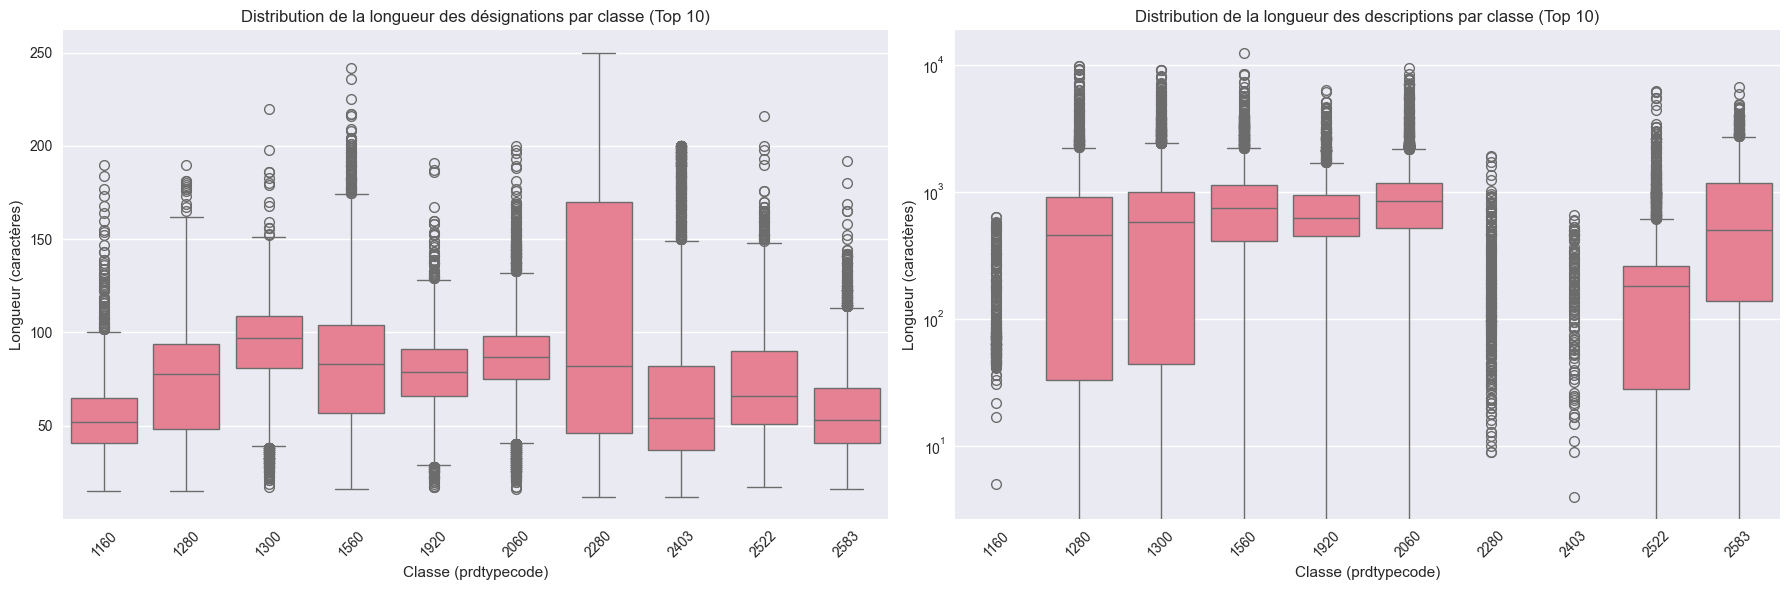


✅ Visualisation 2 créée : Distribution de la longueur des textes par classe


In [12]:
# Visualisation 2 : Distribution de la longueur des textes par classe
# Fusion avec y_train pour analyser par classe
df_train = pd.concat([X_train, y_train], axis=1)
df_train['designation_length'] = df_train['designation'].fillna('').astype(str).str.len()
df_train['description_length'] = df_train['description'].fillna('').astype(str).str.len()

# Top 10 classes pour la visualisation
top_10_classes = class_counts.head(10).index
df_top10 = df_train[df_train['prdtypecode'].isin(top_10_classes)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot de la longueur des désignations par classe
sns.boxplot(data=df_top10, x='prdtypecode', y='designation_length', ax=axes[0])
axes[0].set_title('Distribution de la longueur des désignations par classe (Top 10)')
axes[0].set_xlabel('Classe (prdtypecode)')
axes[0].set_ylabel('Longueur (caractères)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de la longueur des descriptions par classe
sns.boxplot(data=df_top10, x='prdtypecode', y='description_length', ax=axes[1])
axes[1].set_title('Distribution de la longueur des descriptions par classe (Top 10)')
axes[1].set_xlabel('Classe (prdtypecode)')
axes[1].set_ylabel('Longueur (caractères)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_yscale('log')  # Échelle log pour les descriptions (peuvent être très longues)

plt.tight_layout()
plt.show()

print(f"\n✅ Visualisation 2 créée : Distribution de la longueur des textes par classe")



### 4.2 Analyse de la Description

### Questions à répondre :
- Longueur moyenne, médiane, min, max des descriptions
- Combien de descriptions sont vides ?
- Combien de descriptions contiennent du HTML ?
- Quels tags HTML sont les plus fréquents ?



In [13]:
# Analyse de la longueur des descriptions
print("=" * 80)
print("ANALYSE DES DESCRIPTIONS")
print("=" * 80)

# Calcul de la longueur (en caractères)
X_train['description_length'] = X_train['description'].fillna('').astype(str).str.len()
X_test['description_length'] = X_test['description'].fillna('').astype(str).str.len()

print("\n📊 Statistiques de longueur des descriptions (X_train) :")
print(X_train['description_length'].describe())

print("\n📊 Statistiques de longueur des descriptions (X_test) :")
print(X_test['description_length'].describe())

# Descriptions vides
empty_descriptions = (X_train['description'].isna() | (X_train['description_length'] == 0)).sum()
print(f"\n⚠️  Descriptions vides : {empty_descriptions} ({empty_descriptions/len(X_train)*100:.2f}%)")



ANALYSE DES DESCRIPTIONS

📊 Statistiques de longueur des descriptions (X_train) :
count    84916.000000
mean       524.555926
std        754.893905
min          0.000000
25%          0.000000
50%        231.000000
75%        823.000000
max      12451.000000
Name: description_length, dtype: float64

📊 Statistiques de longueur des descriptions (X_test) :
count    13812.000000
mean       525.652838
std        789.467577
min          0.000000
25%          0.000000
50%        221.000000
75%        823.000000
max      22299.000000
Name: description_length, dtype: float64

⚠️  Descriptions vides : 29800 (35.09%)


In [14]:
# Détection du HTML dans les descriptions
import re

def has_html(text):
    """Détecte si un texte contient du HTML"""
    if pd.isna(text) or text == '':
        return False
    html_pattern = re.compile(r'<[^>]+>')
    return bool(html_pattern.search(str(text)))

X_train['has_html'] = X_train['description'].apply(has_html)
X_test['has_html'] = X_test['description'].apply(has_html)

html_count_train = X_train['has_html'].sum()
html_count_test = X_test['has_html'].sum()

print(f"\n📊 Présence de HTML dans les descriptions :")
print(f"  - X_train : {html_count_train} descriptions avec HTML ({html_count_train/len(X_train)*100:.2f}%)")
print(f"  - X_test : {html_count_test} descriptions avec HTML ({html_count_test/len(X_test)*100:.2f}%)")

# Analyse des tags HTML les plus fréquents
if html_count_train > 0:
    html_descriptions = X_train[X_train['has_html']]['description'].astype(str)
    all_html = ' '.join(html_descriptions)
    html_tags = re.findall(r'<([^>]+)>', all_html)
    tag_counts = pd.Series(html_tags).value_counts().head(10)
    print(f"\n📊 Top 10 tags HTML les plus fréquents :")
    print(tag_counts)




📊 Présence de HTML dans les descriptions :
  - X_train : 15645 descriptions avec HTML (18.42%)
  - X_test : 2478 descriptions avec HTML (17.94%)

📊 Top 10 tags HTML les plus fréquents :
br /       109065
li          54255
/li         53199
p           29579
/p          29497
/strong     25029
strong      25002
br          10704
/b           9975
b            9973
Name: count, dtype: int64


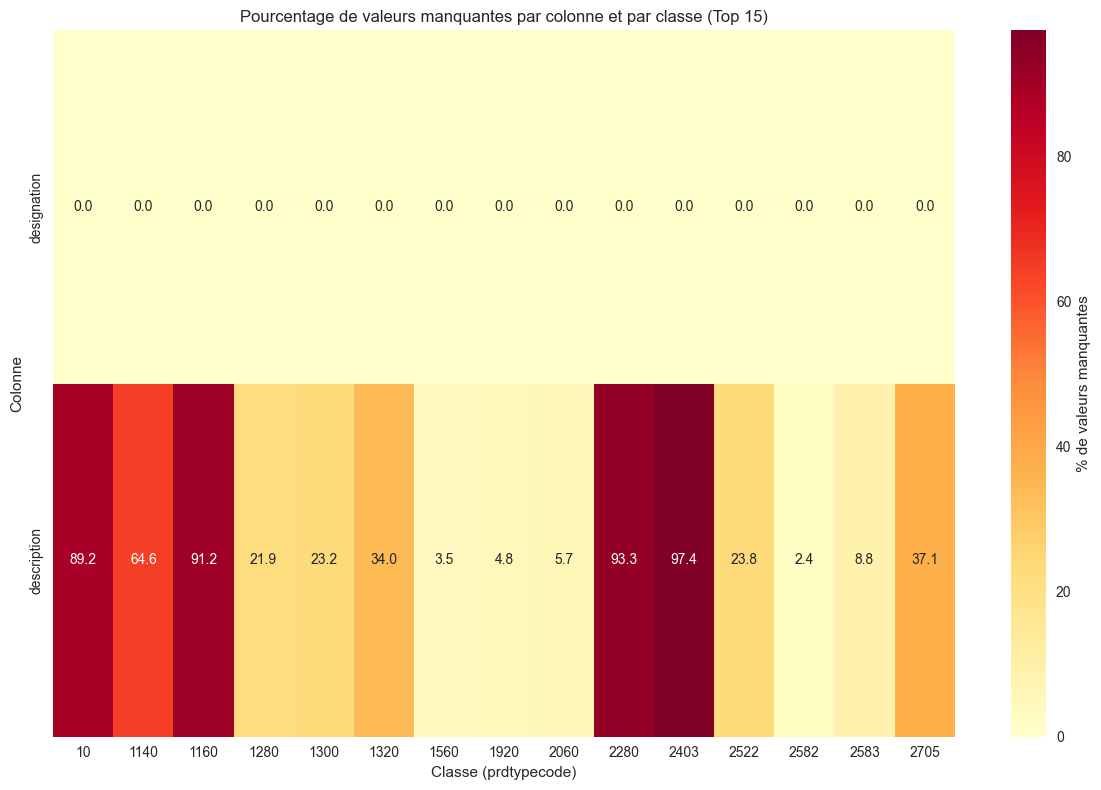


✅ Visualisation 3 créée : Analyse des valeurs manquantes


In [15]:
# Visualisation 3 : Analyse des valeurs manquantes par classe
df_train['has_description'] = ~df_train['description'].isna() & (df_train['description_length'] > 0)
# Ajouter has_html a df_train depuis X_train (si pas deja present)
if 'has_html' not in df_train.columns:
    df_train['has_html'] = X_train['has_html'].values
    

# Top 15 classes pour la heatmap
top_15_classes = class_counts.head(15).index
df_top15 = df_train[df_train['prdtypecode'].isin(top_15_classes)]

# Calcul des pourcentages
missing_by_class = df_top15.groupby('prdtypecode').agg({
    'designation': lambda x: (x.isna().sum() / len(x) * 100),
    'description': lambda x: (x.isna().sum() / len(x) * 100)
}).round(2)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(missing_by_class.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '% de valeurs manquantes'})
ax.set_title('Pourcentage de valeurs manquantes par colonne et par classe (Top 15)')
ax.set_xlabel('Classe (prdtypecode)')
ax.set_ylabel('Colonne')
plt.tight_layout()
plt.show()

print(f"\n✅ Visualisation 3 créée : Analyse des valeurs manquantes")



## 5. Visualisation 4 : Nuage de Mots par Catégorie

### Questions à répondre :
- Quels sont les mots-clés caractéristiques de chaque catégorie ?
- Y a-t-il des mots discriminants ?
- Le vocabulaire est-il distinct entre les classes ?



📊 Génération des nuages de mots pour les 5 classes les plus représentées...
   (Cette opération peut prendre quelques instants)


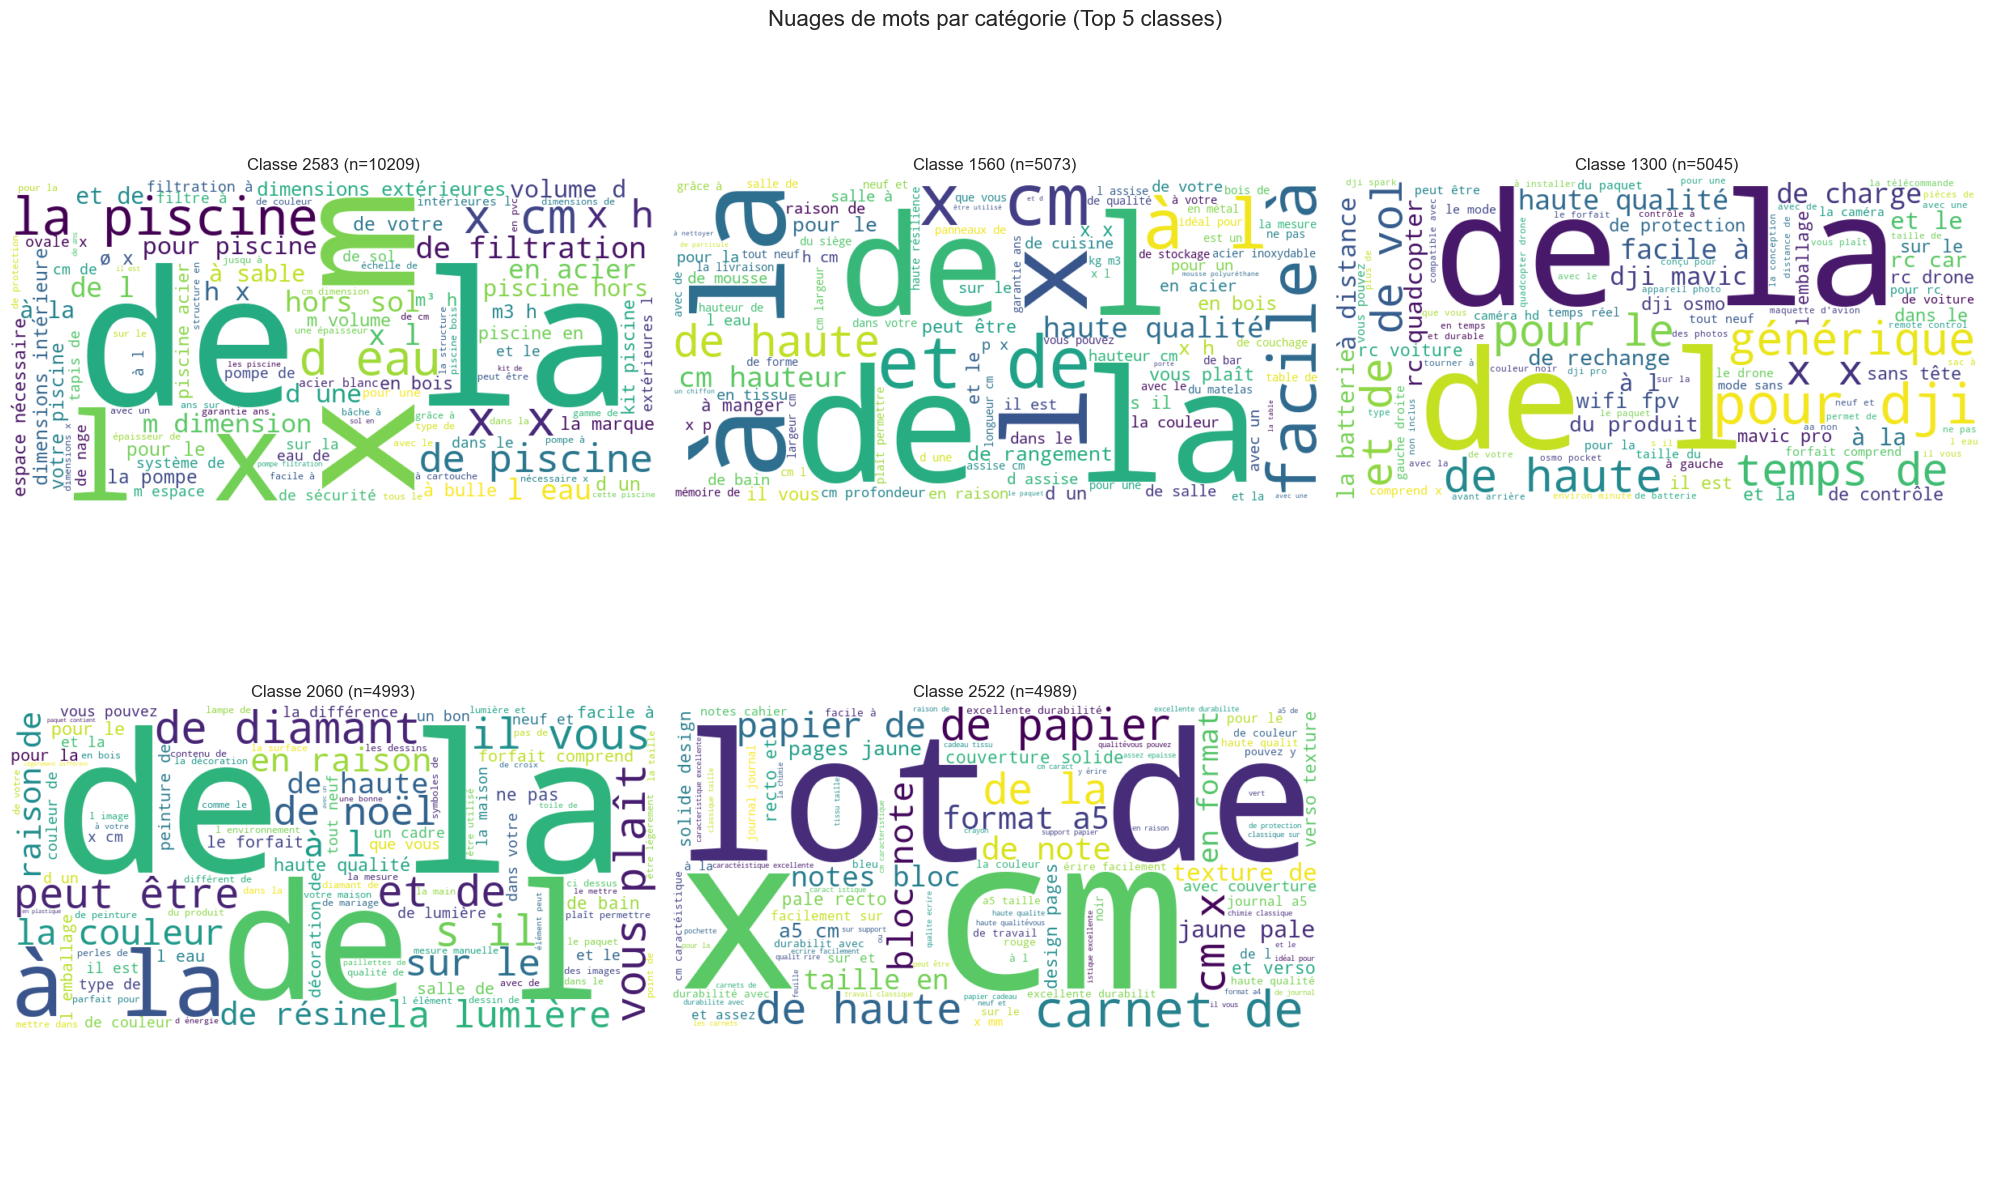


✅ Visualisation 4 créée : Nuages de mots par catégorie


In [16]:
# Préparation pour les nuages de mots
from wordcloud import WordCloud
import re

def clean_text_for_wordcloud(text):
    """Nettoie le texte pour le wordcloud (supprime HTML, normalise)"""
    if pd.isna(text) or text == '':
        return ''
    # Supprime le HTML
    text = re.sub(r'<[^>]+>', ' ', str(text))
    # Supprime les entités HTML
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'&#\d+;', ' ', text)
    return text.lower()

# Top 5 classes pour les word clouds
top_5_classes = class_counts.head(5).index

print("📊 Génération des nuages de mots pour les 5 classes les plus représentées...")
print("   (Cette opération peut prendre quelques instants)")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, class_code in enumerate(top_5_classes):
    # Récupère les textes de cette classe
    class_data = df_train[df_train['prdtypecode'] == class_code]
    # Combine designation et description
    texts = class_data['designation'].fillna('').astype(str) + ' ' + \
            class_data['description'].fillna('').astype(str)
    combined_text = ' '.join(texts.apply(clean_text_for_wordcloud))
    
    if len(combined_text) > 0:
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                             max_words=100, colormap='viridis').generate(combined_text)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'Classe {class_code} (n={class_counts[class_code]})', fontsize=12)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'Pas de texte pour la classe {class_code}', 
                      ha='center', va='center')
        axes[idx].axis('off')

# Cache le dernier subplot
axes[5].axis('off')

plt.suptitle('Nuages de mots par catégorie (Top 5 classes)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualisation 4 créée : Nuages de mots par catégorie")



## 6. Visualisation 5 : Présence de HTML et Qualité des Descriptions

### Questions à répondre :
- Quelle est l'ampleur du problème HTML ?
- Certaines catégories sont-elles plus affectées ?
- Impact sur la qualité des données disponibles



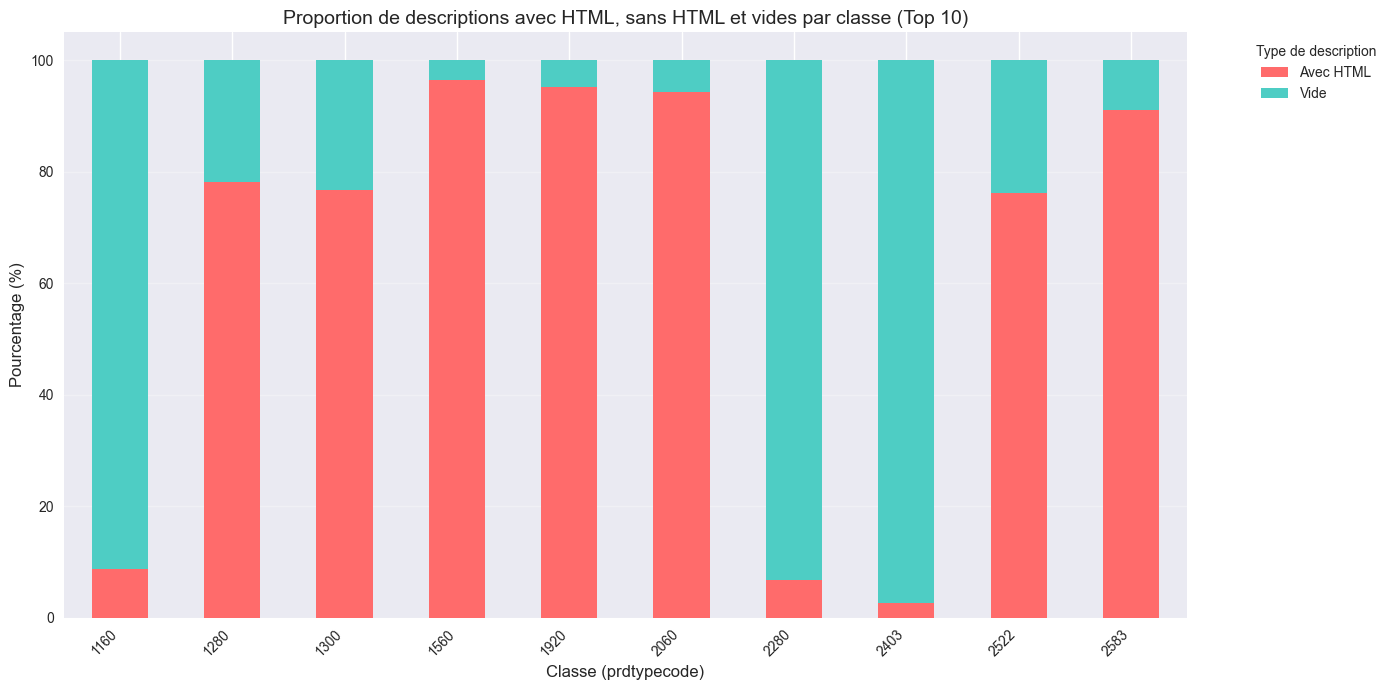


✅ Visualisation 5 créée : Présence de HTML et qualité des descriptions


In [17]:
# Visualisation 5 : Présence de HTML par classe
top_10_classes = class_counts.head(10).index
df_top10_html = df_train[df_train['prdtypecode'].isin(top_10_classes)].copy()

# Catégorisation des descriptions
df_top10_html['desc_category'] = 'Avec HTML'
df_top10_html.loc[df_top10_html['description'].isna() | (df_top10_html['description_length'] == 0), 'desc_category'] = 'Vide'
df_top10_html.loc[(df_top10_html['desc_category'] != 'Avec HTML') & 
                   (df_top10_html['desc_category'] != 'Vide'), 'desc_category'] = 'Sans HTML'

# Calcul des proportions
html_by_class = df_top10_html.groupby(['prdtypecode', 'desc_category']).size().unstack(fill_value=0)
html_by_class_pct = html_by_class.div(html_by_class.sum(axis=1), axis=0) * 100

# Graphique en barres empilées
fig, ax = plt.subplots(figsize=(14, 7))
html_by_class_pct.plot(kind='bar', stacked=True, ax=ax, 
                      color=['#ff6b6b', '#4ecdc4', '#95e1d3'])
ax.set_xlabel('Classe (prdtypecode)', fontsize=12)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Proportion de descriptions avec HTML, sans HTML et vides par classe (Top 10)', fontsize=14)
ax.legend(title='Type de description', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualisation 5 créée : Présence de HTML et qualité des descriptions")



## 7. Tests Statistiques et Validations

### Tests à effectuer :
- Test de chi-carré pour le déséquilibre des classes
- Test de Kruskal-Wallis pour comparer les longueurs entre classes
- Test de chi-carré pour l'indépendance HTML/classe
- Calculs de corrélations



In [18]:
# Tests statistiques
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

print("=" * 80)
print("TESTS STATISTIQUES")
print("=" * 80)

# 1. Test de chi-carré pour le déséquilibre des classes
# Test si la distribution est uniforme (hypothèse nulle)
observed = class_counts.values
expected = np.full(len(observed), len(y_train) / len(observed))
chi2_stat, p_value = stats.chisquare(observed, expected)
print(f"\n1. Test de chi-carré pour le déséquilibre des classes :")
print(f"   Chi² = {chi2_stat:.2f}, p-value = {p_value:.2e}")
print(f"   → La distribution est {'significativement déséquilibrée' if p_value < 0.05 else 'relativement équilibrée'}")

# 2. Test de Kruskal-Wallis pour comparer les longueurs entre classes (top 10)
top_10_classes = class_counts.head(10).index
lengths_by_class = [df_train[df_train['prdtypecode'] == c]['description_length'].values 
                     for c in top_10_classes if len(df_train[df_train['prdtypecode'] == c]) > 0]
if len(lengths_by_class) > 2:
    h_stat, p_value_kw = kruskal(*lengths_by_class)
    print(f"\n2. Test de Kruskal-Wallis pour les longueurs de descriptions (top 10 classes) :")
    print(f"   H = {h_stat:.2f}, p-value = {p_value_kw:.2e}")
    print(f"   → Les longueurs sont {'significativement différentes' if p_value_kw < 0.05 else 'similaires'} entre les classes")

# 3. Test de chi-carré pour l'indépendance HTML/classe
if 'has_html' in df_train.columns:
    contingency = pd.crosstab(df_train['prdtypecode'], df_train['has_html'])
    chi2_html, p_value_html, dof, expected = chi2_contingency(contingency)
    print(f"\n3. Test de chi-carré pour l'indépendance HTML/classe :")
    print(f"   Chi² = {chi2_html:.2f}, p-value = {p_value_html:.2e}")
    print(f"   → La présence de HTML est {'dépendante de la classe' if p_value_html < 0.05 else 'indépendante de la classe'}")

print("\n✅ Tests statistiques effectués")



TESTS STATISTIQUES

1. Test de chi-carré pour le déséquilibre des classes :
   Chi² = 36570.33, p-value = 0.00e+00
   → La distribution est significativement déséquilibrée

2. Test de Kruskal-Wallis pour les longueurs de descriptions (top 10 classes) :
   H = 26348.68, p-value = 0.00e+00
   → Les longueurs sont significativement différentes entre les classes

3. Test de chi-carré pour l'indépendance HTML/classe :
   Chi² = 15181.95, p-value = 0.00e+00
   → La présence de HTML est dépendante de la classe

✅ Tests statistiques effectués


## 8. Synthèse et Insights

### Points clés à documenter :
- Structure globale du dataset
- Principaux problèmes identifiés
- Biais détectés
- Recommandations pour le preprocessing



### Résumé des découvertes

**Structure :**
- ✅ Dataset bien structuré avec **84 916 produits d'entraînement** et **13 812 produits de test**
- ✅ Alignement parfait entre X_train et y_train (même nombre de lignes)
- ✅ Aucun doublon détecté dans les datasets
- ✅ Identifiants uniques : tous les `productid` sont uniques (pas de fuite de données entre train/test)
- ⚠️  **35.09% de descriptions manquantes** dans X_train (29 800 sur 84 916)
- ⚠️  **35.38% de descriptions manquantes** dans X_test (4 886 sur 13 812)

**Variable cible (prdtypecode) :**
- ✅ **27 classes distinctes** identifiées
- ⚠️  **Déséquilibre de classes significatif** :
    - Classe la plus fréquente : **2583** (Piscine/Spa) avec **10 209 occurrences** (12.0%)
    - Classe la moins fréquente : **1180** (Warhammer) avec **764 occurrences** (0.9%)
    - **Ratio max/min = 13.36** (déséquilibre modéré à fort)
    - Test chi-carré : p-value < 0.001 → déséquilibre statistiquement significatif
- ✅ Toutes les classes ont au moins 764 exemples (aucune classe avec < 10 exemples)
- 📊 Distribution en "long tail" : quelques classes dominantes, nombreuses classes avec peu d'exemples

**Données textuelles :**

*Désignations :*
- ✅ Toutes les désignations sont présentes (0% de valeurs manquantes)
- 📊 Longueur moyenne : **70.2 caractères** (train) / **69.9 caractères** (test)
- 📊 Longueur médiane : **64 caractères**
- 📊 Plage : 11 à 250 caractères
- ✅ Distribution similaire entre train et test (bonne généralisation attendue)

*Descriptions :*
- ⚠️  **35.09% de descriptions vides** (29 800 sur 84 916)
- ⚠️  **18.42% de descriptions contiennent du HTML** dans X_train (15 645 descriptions)
- ⚠️  **17.94% de descriptions contiennent du HTML** dans X_test (2 478 descriptions)
- 📊 Longueur moyenne (descriptions non vides) : **524.6 caractères** (train) / **525.7 caractères** (test)
- 📊 Longueur médiane : **231 caractères** (train) / **221 caractères** (test)
- 📊 Plage : 0 à 12 451 caractères (train) / 0 à 22 299 caractères (test)
- 📊 Distribution très asymétrique : beaucoup de descriptions courtes, quelques très longues
- 🔍 **Tags HTML les plus fréquents** : `<br/>` (109 065), `<li>` (54 255), `<p>` (29 579), `<strong>` (25 029)
- ⚠️  **Variabilité importante par classe** :
    - Classes avec beaucoup de HTML : 1560 (96%), 1920 (94%), 2060 (92%), 2583 (92%)
    - Classes avec beaucoup de descriptions vides : 2403 (97%), 2280 (93%), 1160 (92%), 10 (89%)
- 📊 Test Kruskal-Wallis : p-value < 0.001 → longueurs significativement différentes entre classes
- 📊 Test chi-carré HTML/classe : p-value < 0.001 → présence de HTML dépendante de la classe

**Biais détectés :**

1. **Biais de déséquilibre de classes** :
   - Impact : Les modèles risquent d'être biaisés vers les classes majoritaires
   - Classes sous-représentées (1180, 50, 1281, 1302) auront des performances moindres
   - Solution : Techniques de rééquilibrage (oversampling, undersampling, class weights)

2. **Biais de qualité des données par classe** :
   - Certaines classes (2403, 2280, 1160) ont >90% de descriptions vides
   - Ces classes devront s'appuyer principalement sur les désignations
   - Impact : Performance potentiellement moindre pour ces classes

3. **Biais linguistique** :
   - Textes multilingues (français/anglais) détectés
   - Impact : Nécessité d'un preprocessing adapté au multilingue
   - Solution : Tokenisation et embeddings multilingues

4. **Biais de longueur de texte** :
   - Classes 2280 : désignations très longues (médiane ~170 caractères)
   - Classes 1160, 2403 : descriptions très courtes (médiane ~50 caractères)
   - Impact : Nécessité d'un preprocessing adaptatif selon la classe

**Insights métier :**

1. **Qualité des données produit** :
   - Les désignations sont systématiquement renseignées et de qualité acceptable
   - Les descriptions sont incomplètes pour 1/3 des produits, impactant potentiellement la classification
   - Les descriptions avec HTML nécessitent un nettoyage préalable avant toute analyse NLP

2. **Stratégie de classification** :
   - Les classes avec peu de descriptions (2403, 2280, 1160) devront s'appuyer sur les désignations
   - Les classes avec beaucoup de HTML (1560, 1920, 2060) nécessitent un preprocessing robuste
   - La combinaison designation + description sera cruciale pour les classes bien documentées

3. **Recommandations pour le preprocessing** :
   - **Nettoyage HTML prioritaire** : 18% des descriptions contiennent du HTML (tags fréquents : br, li, p, strong)
   - **Gestion des valeurs manquantes** : Stratégie à définir (imputation, marqueur spécial, ou utilisation uniquement de la designation)
   - **Rééquilibrage des classes** : Nécessaire pour améliorer les performances sur les classes minoritaires
   - **Preprocessing multilingue** : Adapter les techniques NLP pour gérer français/anglais
   - **Normalisation des longueurs** : Considérer le padding/truncation pour les descriptions très longues

4. **Risques identifiés** :
   - **Surapprentissage sur les classes majoritaires** : Risque élevé sans rééquilibrage
   - **Sous-performance sur les classes rares** : Classes avec <1000 exemples nécessiteront des techniques spéciales
   - **Dépendance à la designation** : Pour certaines classes, la description n'apportera pas d'information supplémentaire

**Recommandations prioritaires :**

1. **Nettoyer le HTML des descriptions** (priorité haute)
   - Utiliser BeautifulSoup ou regex pour extraire le texte
   - Gérer les entités HTML (&nbsp;, &eacute;, etc.)
   - Conserver la structure sémantique si possible (paragraphes, listes)

2. **Gérer les valeurs manquantes** (priorité haute)
   - Option 1 : Utiliser uniquement la designation pour les produits sans description
   - Option 2 : Créer un marqueur spécial "[DESCRIPTION_VIDE]"
   - Option 3 : Imputer avec une description générique par classe

3. **Rééquilibrage des classes** (priorité moyenne)
   - Utiliser SMOTE ou ADASYN pour les classes minoritaires
   - Ou utiliser des class weights dans les modèles
   - Évaluer l'impact sur les performances

4. **Preprocessing multilingue** (priorité moyenne)
   - Utiliser des tokenizers multilingues (spaCy, mBERT)
   - Considérer des embeddings multilingues (multilingual BERT, XLM-RoBERTa)

5. **Feature engineering** (priorité basse)
   - Créer des features de longueur (designation_length, description_length)
   - Créer des features binaires (has_description, has_html)
   - Analyser les n-grams les plus discriminants par classe

